<a href="https://colab.research.google.com/github/sandhya14-automation/RoBERTa_News_Topic_Classifier_Transformer_Project/blob/main/Transformer_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RoBERTa News Topic Classifier (AG News)**

In [ ]:
# 1. Install Required Libraries

!pip install --upgrade transformers datasets evaluate optuna accelerate -q

In [ ]:
# 2. Import Libraries

from datasets import load_dataset
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from transformers import TrainingArguments, Trainer
import evaluate
import numpy as np
import optuna
import torch

In [ ]:
 # 3. Load the AG News Dataset

dataset = load_dataset("ag_news")

In [ ]:
# 4. Load Tokenizer

model_name = "distilroberta-base"
tokenizer = RobertaTokenizerFast.from_pretrained(model_name)

In [ ]:
# 5. Tokenize the Dataset

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=64)

tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
# 6. Use a Smaller Training Subset (20,000 samples)

small_train = tokenized_dataset["train"].shuffle(seed=42).select(range(20000))

In [ ]:
# 7. Define Evaluation Metric (Accuracy + Macro‑F1)

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

In [ ]:
# 8. Optuna Hyperparameter Tuning

def objective(trial):

    # 1. Suggest hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-6, 5e-5)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    num_epochs = trial.suggest_int("num_epochs", 1, 3)

    # 2. Training arguments using trial values
    training_args = TrainingArguments(
        output_dir="optuna-roberta",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        logging_steps=50,
        report_to="none"
    )

    # 3. Create model + trainer
    model = RobertaForSequenceClassification.from_pretrained(
        model_name, num_labels=4, ignore_mismatched_sizes=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=small_train,
        eval_dataset=tokenized_dataset["test"],
        compute_metrics=compute_metrics
    )

    # 4. Train + evaluate
    trainer.train()
    eval_results = trainer.evaluate()

    # 5. Return macro-F1 to maximize
    return eval_results["eval_macro_f1"]


# Run Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=3)

print("Best hyperparameters:", study.best_params)

[I 2026-02-09 04:33:14,705] A new study created in memory with name: no-name-f1a7e0dd-5a28-4007-8c34-01f98f4d4eda


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.982448,0.997018,0.581447,0.570797
2,0.852516,0.854289,0.665263,0.661427
3,0.709333,0.758063,0.705526,0.703525


[I 2026-02-09 04:39:52,767] Trial 0 finished with value: 0.7035246357971036 and parameters: {'learning_rate': 3.891818590945999e-05, 'batch_size': 32, 'num_epochs': 3}. Best is trial 0 with value: 0.7035246357971036.


...

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.317448,1.296116,0.390526,0.373959


[I 2026-02-09 04:47:30,543] Trial 2 finished with value: 0.3739586834577312 and parameters: {'learning_rate': 1.185788185268216e-06, 'batch_size': 8, 'num_epochs': 1}. Best is trial 0 with value: 0.7035246357971036.


Best hyperparameters: {'learning_rate': 3.891818590945999e-05, 'batch_size': 32, 'num_epochs': 3}


In [ ]:
# 9. Train Final Model Using Best Hyperparameters

best = study.best_params

training_args = TrainingArguments(
    output_dir="roberta-news",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=best["learning_rate"],
    per_device_train_batch_size=best["batch_size"],
    per_device_eval_batch_size=best["batch_size"],
    num_train_epochs=best["num_epochs"],
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True
)

model = RobertaForSequenceClassification.from_pretrained(
    model_name, num_labels=4, ignore_mismatched_sizes=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.060817,1.089515,0.535000,0.517125
2,0.894243,0.905872,0.643816,0.638341
3,0.790219,0.806460,0.681053,0.678887


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1875, training_loss=0.9857581909179688, metrics={'train_runtime': 405.0062, 'train_samples_per_second': 148.146, 'train_steps_per_second': 4.63, 'total_flos': 993540925440000.0, 'train_loss': 0.9857581909179688, 'epoch': 3.0})

In [ ]:
# 10. Evaluate the Model

trainer.evaluate()

{'eval_loss': 0.8064596652984619,
 'eval_accuracy': 0.6810526315789474,
 'eval_macro_f1': 0.6788872442600811,
 'eval_runtime': 13.7966,
 'eval_samples_per_second': 550.859,
 'eval_steps_per_second': 17.251,
 'epoch': 3.0}

In [ ]:
# 11. Predict Headline function

def predict_headline(text):
    # tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # move inputs to same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # forward pass
    outputs = model(**inputs)

    # prediction
    pred = torch.argmax(outputs.logits, dim=1).item()

    labels = ["World", "Sports", "Business", "Sci/Tech"]
    return labels[pred]

predict_headline("Apple releases new iPhone model")

'Sci/Tech'

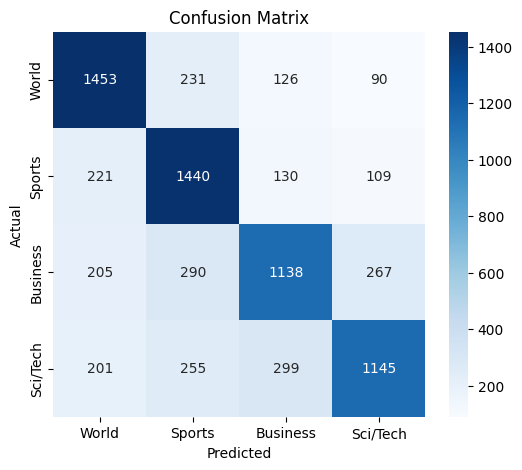

In [ ]:
# 12. Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = trainer.predict(tokenized_dataset["test"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["World", "Sports", "Business", "Sci/Tech"],
            yticklabels=["World", "Sports", "Business", "Sci/Tech"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# 13. Save Model for Later Use

model.save_pretrained("final_roberta_model")
tokenizer.save_pretrained("final_roberta_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('final_roberta_model/tokenizer_config.json',
 'final_roberta_model/tokenizer.json')